Import des lib 
| ctype pour le C
| Pillow pour la conversion image to vecteur

In [29]:
import ctypes
import matplotlib.pyplot as plt
from PIL import Image

Definition des fonction de la lib C

In [18]:
lib = ctypes.CDLL("./cmake-build-debug/libProjet_Annuel_3IABD.dll")

c_int = ctypes.c_int
c_double = ctypes.c_double
c_void_p = ctypes.c_void_p

c_double_p = ctypes.POINTER(c_double)
c_double_p_p = ctypes.POINTER(c_double_p)
c_int_p = ctypes.POINTER(c_int)

lib.init_pmc.argtypes = [c_int_p, c_int, c_double]
lib.init_pmc.restype = c_void_p

lib.train.argtypes = [c_void_p, c_double_p, c_double_p, c_int, c_int, c_int]
lib.train.restype = c_double

lib.propagation.argtypes = [c_void_p, c_double_p_p, c_int, c_double_p_p]
lib.propagation.restype = None

lib.predict.argtypes = [c_void_p, c_double_p, c_int, c_int, c_int]
lib.predict.restype = c_double_p

lib.free_p.argtypes = [c_double_p]
lib.free_p.restype = None

lib.free_pmc.argtypes = [c_void_p]
lib.free_pmc.restype = None

Conversion Image -> vecteur normalisé de pixel (pour avoir des valeurs entre 0 et 1 (sympa pour notre sigmoid))

In [19]:
def image_to_vector(path):
    img = Image.open(path).convert("RGB")

    return [
        c / 255.0
        for pixel in img.get_flattened_data()
        for c in pixel
    ]

Cas de test XOR

In [8]:
layers = (c_int * 3)(2, 2, 1)
model = lib.init_pmc(layers, 3, 1)

nb_sample = 4
nb_data_per_sample = 2

input = (c_double * (nb_sample * nb_data_per_sample))(
    0.0, 0.0,
    0.0, 1.0,
    1.0, 0.0,
    1.0, 1.0
)

y_true = (c_double * nb_sample)(
    0.0,
    1.0,
    1.0,
    0.0
)

epochs = 100_000
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, 4, 2, 1)
    losses.append(loss)

    if epoch % 10000 == 0:
        print(epoch, loss)

pred_ptr = lib.predict(model, input, 4, 2, 1)

for i in range(4):
    in0 = input[i * 2]
    in1 = input[i * 2 + 1]
    y = pred_ptr[i]
    print(f"[{in0}, {in1}] -> {y}")

lib.free_p(pred_ptr)
lib.free_pmc(model)

0 0.25047170525466034
10000 0.24999994964561356
20000 0.24999984745120285
30000 0.249999618632809
40000 0.24999856184011887
50000 0.17711871704815418
60000 0.0006206008477677268
70000 0.0002825572328111711
80000 0.0001813370574294792
90000 0.00013305851419795502
[0.0, 0.0] -> 0.009413676098950066
[0.0, 1.0] -> 0.9892915291776435
[1.0, 0.0] -> 0.989285388721351
[1.0, 1.0] -> 0.010074765505637915


Cas de test Data Set

Declaration des images sous forme de vecteur

In [55]:
v_img_recyclable_0 = image_to_vector("data_set/64/training_data/recyclable-000.jpg")
v_img_recyclable_1 = image_to_vector("data_set/64/training_data/recyclable-001.jpg")
v_img_recyclable_2 = image_to_vector("data_set/64/training_data/recyclable-004.jpg")

v_img_compost_0    = image_to_vector("data_set/64/training_data/compost-000.jpg")
v_img_compost_1    = image_to_vector("data_set/64/training_data/compost-001.jpg")
v_img_compost_2    = image_to_vector("data_set/64/training_data/compost-002.jpg")

v_img_pile_0       = image_to_vector("data_set/64/training_data/pile-003.jpg")
v_img_pile_1       = image_to_vector("data_set/64/training_data/pile-004.jpg")
v_img_pile_2       = image_to_vector("data_set/64/training_data/pile-005.jpg")


Initialisation du Model

In [68]:

nb_sample = 9
nb_data_per_sample = 64*64 * 3

layers = (c_int * 3)(nb_data_per_sample, 8, 3)
nb_layers = 3
learning_rate = 1
model = lib.init_pmc(layers, nb_layers, learning_rate)


Initialisation des tableau d'Input et de valeur cibles

In [64]:

input = (c_double * (nb_sample * nb_data_per_sample))(
    *v_img_recyclable_0,
    *v_img_recyclable_1,
    *v_img_recyclable_2,

    *v_img_compost_0,
    *v_img_compost_1,
    *v_img_compost_2,

    *v_img_pile_0,
    *v_img_pile_1,
    *v_img_pile_2,
)

y_true = (c_double * (nb_sample * 3))(
    *[1.0, 0.0, 0.0], # Recyclable
    *[1.0, 0.0, 0.0], # Recyclable
    *[1.0, 0.0, 0.0], # Recyclable

    *[0.0, 1.0, 0.0], # Compost
    *[0.0, 1.0, 0.0], # Compost
    *[0.0, 1.0, 0.0], # Compost

    *[0.0, 0.0, 1.0], # Pile
    *[0.0, 0.0, 1.0], # Pile
    *[0.0, 0.0, 1.0], # Pile
)

Entrainement vigoureux et semé d'embuches

In [69]:
epochs = 500
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 3)
    losses.append(loss)

    if epoch % 100 == 0:
        print(epoch, loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 3)

labels = ["recyclable", "compost   ", "pile      "]

for i in range(nb_sample):
    p0 = pred_ptr[i * 3]
    p1 = pred_ptr[i * 3 + 1]
    p2 = pred_ptr[i * 3 + 2]

    scores = [p0, p1, p2]
    predicted_class = labels[scores.index(max(scores))]
    
    print(f"image {i} -> {predicted_class} | scores = [{p0:.3f}, {p1:.3f}, {p2:.3f}]")

lib.free_pmc(model)

0 0.2587347367141419
100 0.0592743653743834
200 0.010847591840257638
300 0.00550028479654518
400 0.003597951406582462
image 0 -> recyclable | scores = [0.949, 0.033, 0.041]
image 1 -> recyclable | scores = [0.949, 0.033, 0.041]
image 2 -> recyclable | scores = [0.949, 0.034, 0.041]
image 3 -> compost    | scores = [0.033, 0.935, 0.052]
image 4 -> compost    | scores = [0.032, 0.935, 0.053]
image 5 -> compost    | scores = [0.033, 0.934, 0.054]
image 6 -> pile       | scores = [0.042, 0.051, 0.958]
image 7 -> pile       | scores = [0.047, 0.049, 0.911]
image 8 -> pile       | scores = [0.030, 0.075, 0.952]


Plot de cette horreur

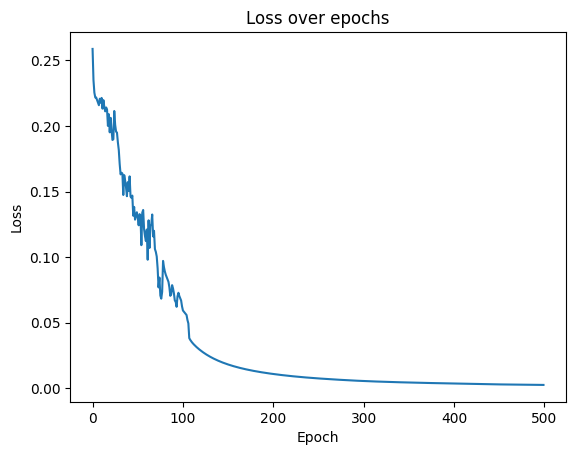

In [70]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.show()

Commentaires : J'ai du enormement compresser les images d'input pour que le model tourne dans des delais raisonnable (original -> 300*300 -> 64*64)

1h pour 10_000 epoch avec 9 images a 300*300 pour du .24 de loss final